In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

features = pd.read_parquet(DATA_PROCESSED / "features.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

sup_backtest = pd.read_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

features.index = pd.to_datetime(features.index)
returns.index = pd.to_datetime(returns.index)
sup_backtest.index = pd.to_datetime(sup_backtest.index)

In [3]:
REBALANCE_EVERY = 10
LONG_Q = 0.8
SHORT_Q = 0.2
TRANSACTION_COST = 0.001
TRAIN_RATIO = 0.7

In [4]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    drawdown = equity / equity.cummax() - 1

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
    })

In [5]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(0.0, index=score_df.columns)

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(0.0, index=score_df.columns)
            new_position.loc[scores[scores >= long_threshold].index] = 1.0
            new_position.loc[scores[scores <= short_threshold].index] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [6]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    net = gross - transaction_cost * turnover

    return net, turnover

In [7]:
momentum_20 = features.xs("momentum_20", axis=1, level="feature")
momentum_60 = features.xs("momentum_60", axis=1, level="feature")
volatility_20 = features.xs("volatility_20", axis=1, level="feature")
volatility_60 = features.xs("volatility_60", axis=1, level="feature")

In [8]:
def cross_sectional_zscore(df):
    return df.sub(df.mean(axis=1), axis=0).div(
        df.std(axis=1).replace(0, np.nan),
        axis=0
    )

In [9]:
z_mom20 = cross_sectional_zscore(momentum_20)
z_mom60 = cross_sectional_zscore(momentum_60)

z_vol20 = cross_sectional_zscore(volatility_20)
z_vol60 = cross_sectional_zscore(volatility_60)

In [10]:
scores = {}

scores["contrarian_mom60"] = -z_mom60

scores["contrarian_mom20"] = -z_mom20

scores["vol60_only"] = z_vol60

scores["contrarian_mom60_vol60"] = -z_mom60 + z_vol60

scores["contrarian_mom20_vol20"] = -z_mom20 + z_vol20

scores["contrarian_mom20_mom60_vol20_vol60"] = (
    -z_mom20
    -z_mom60
    +z_vol20
    +z_vol60
)

In [11]:
test_index = sup_backtest.index

test_start = test_index.min()
test_end = test_index.max()

test_start, test_end

(Timestamp('2022-03-09 00:00:00'), Timestamp('2024-12-16 00:00:00'))

In [12]:
manual_returns = {}
manual_turnovers = {}

for name, score_df in scores.items():
    score_test = score_df.loc[test_start:test_end]

    positions = build_rebalanced_positions_from_scores(
        score_test,
        rebalance_every=REBALANCE_EVERY,
        long_q=LONG_Q,
        short_q=SHORT_Q
    )

    port_ret, turnover = portfolio_returns_from_positions(
        positions,
        returns,
        transaction_cost=TRANSACTION_COST
    )

    manual_returns[name] = port_ret.loc[test_start:test_end]
    manual_turnovers[name] = turnover.loc[test_start:test_end]

In [13]:
comparison = pd.concat(
    [
        sup_backtest[["supervised_vae_direct", "raw_feature_ridge"]],
        pd.concat(manual_returns, axis=1)
    ],
    axis=1
).dropna()

stats = comparison.apply(performance_stats).T

stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
vol60_only,0.134117,0.046485,0.072385,0.642201,-0.113546
contrarian_mom60_vol60,0.094730,0.033216,0.061218,0.542583,-0.077459
contrarian_mom20_vol20,0.064149,0.022701,0.055836,0.406565,-0.076847
contrarian_mom20_mom60_vol20_vol60,0.055417,0.019663,0.060189,0.326691,-0.110234
contrarian_mom60,-0.027290,-0.009940,0.055201,-0.180060,-0.054796
contrarian_mom20,-0.057817,-0.021272,0.051246,-0.415098,-0.110569


In [14]:
turnover_stats = {
    "supervised_vae_direct": np.nan,
    "raw_feature_ridge": np.nan,
}

for name, turnover in manual_turnovers.items():
    turnover_stats[name] = turnover.mean()

turnover_stats = pd.Series(turnover_stats)

turnover_stats

supervised_vae_direct                      NaN
raw_feature_ridge                          NaN
contrarian_mom60                      0.026934
contrarian_mom20                      0.043935
vol60_only                            0.008883
contrarian_mom60_vol60                0.021394
contrarian_mom20_vol20                0.038013
contrarian_mom20_mom60_vol20_vol60    0.027030
dtype: float64

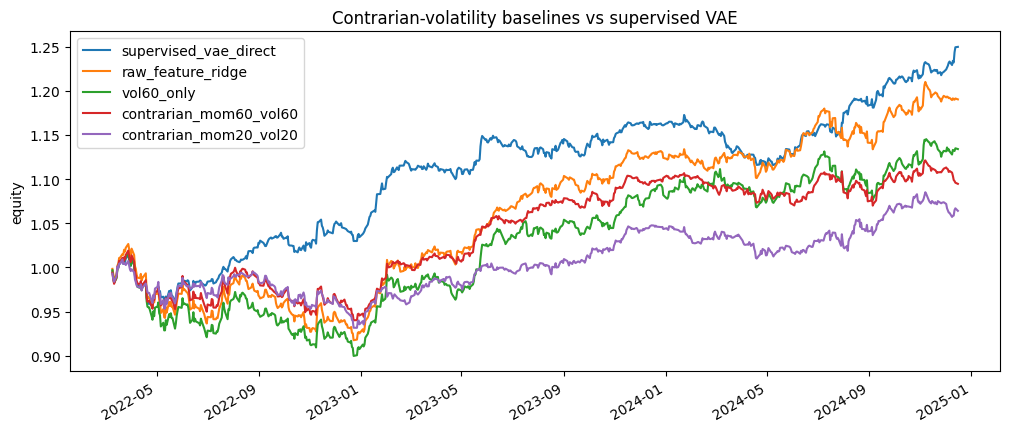

In [15]:
top_models = stats.sort_values("sharpe", ascending=False).head(5).index

equity = (1 + comparison[top_models]).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Contrarian-volatility baselines vs supervised VAE"
)

plt.ylabel("equity")
plt.show()

In [16]:
comparison.to_parquet(
    DATA_BACKTESTS / "contrarian_baseline_comparison_returns.parquet"
)

stats.to_csv(
    DATA_BACKTESTS / "contrarian_baseline_comparison_stats.csv"
)

In [17]:
stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
vol60_only,0.134117,0.046485,0.072385,0.642201,-0.113546
contrarian_mom60_vol60,0.094730,0.033216,0.061218,0.542583,-0.077459
contrarian_mom20_vol20,0.064149,0.022701,0.055836,0.406565,-0.076847
contrarian_mom20_mom60_vol20_vol60,0.055417,0.019663,0.060189,0.326691,-0.110234
contrarian_mom60,-0.027290,-0.009940,0.055201,-0.180060,-0.054796
contrarian_mom20,-0.057817,-0.021272,0.051246,-0.415098,-0.110569
